In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [1]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
train = pd.read_csv(r"C:\Users\Sean\Documents\GitHub\spring-2026-valuation-of-stringed-instruments-II\train.csv")
val = pd.read_csv(r"C:\Users\Sean\Documents\GitHub\spring-2026-valuation-of-stringed-instruments-II\train.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'location_filled', 'date', 'usd', 'gbp', 'eur']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "str", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")



sale_date has 941 unique values
maker_name has 3060 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
lot has 1244 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
role has 34 unique values
maker_last_name has 2164 unique values


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [7]:
LowCardCols = ["type", "bold_currency"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

In [8]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [9]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [10]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [11]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)




In [12]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])



In [13]:
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [14]:
#converting predictions back to USD
forest_pred = np.expm1(rf.predict(X_valid))

rmse = mean_squared_error(Y_valid, forest_pred)
r2 = r2_score(Y_valid, forest_pred)
mae = mean_absolute_error(Y_valid, forest_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)



RMSE: 13099438297.958015
R^2: 0.5920659932219328
mae: 7833.409074355258


We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [15]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train))



c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [16]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

#errors in log prices
rmse = mean_squared_error(np.log1p(Y_valid), lasso_pred)
r2 = r2_score(np.log1p(Y_valid), lasso_pred)
mae = mean_absolute_error(np.log1p(Y_valid), lasso_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)

#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("Optimal alpha:", f"{optimal_alpha:.5f}")


RMSE: 0.3648232643919615
R^2: 0.7959691595789797
mae: 0.4582347083976072
Optimal alpha: 0.00125


In [17]:
#prediction in USD
lasso_pred_dollars = np.expm1(lasso_pred)

#mape and mae instead of r^2 and rmse
mape = mean_absolute_percentage_error(Y_valid, lasso_pred_dollars)
mae = mean_absolute_error(Y_valid, lasso_pred_dollars)
print("mape:", mape)
print("mae:", mae)

mape: 0.5785686668568651
mae: 13450.353707182236


In [18]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [19]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
highcard__city_maker
num__gbp_usd_x
num__SP500_30d_ret
num__SP500_ma200
num__SP500_trend_ratio
num__SP500_vol_30d
num__Year
num__cpi_usd


In [21]:
#prints each feature and its corresponding coefficient
feature_and_coeff = []
for i in range(len(feature_names)):
    feature_and_coeff.append( ( feature_names[i], coefficients[i] ))
for x in feature_and_coeff:
    print(x)

('lognum__real_price_gold', np.float64(-0.017604000745497894))
('lognum__SP500_real', np.float64(0.011414798751330333))
('lowcard__type_Bass', np.float64(0.003945269665350769))
('lowcard__type_Bass Bow', np.float64(-0.0))
('lowcard__type_Bass Viol', np.float64(0.0))
('lowcard__type_Cello', np.float64(0.8145140726133887))
('lowcard__type_Cello Bow', np.float64(-0.04427521795670521))
('lowcard__type_Miscellaneous', np.float64(0.0))
('lowcard__type_Small Violin', np.float64(-0.2640342850480332))
('lowcard__type_Tenor Viol', np.float64(0.0))
('lowcard__type_Treble Viol', np.float64(0.0))
('lowcard__type_Viola', np.float64(0.05980785226281752))
('lowcard__type_Viola Bow', np.float64(-0.0))
("lowcard__type_Viola d'Amore", np.float64(0.0))
('lowcard__type_Violin', np.float64(0.017512778954012747))
('lowcard__type_Violin Bow', np.float64(-0.1433417664861985))
('lowcard__bold_currency_eur', np.float64(-0.014867074273187942))
('lowcard__bold_currency_gbp', np.float64(0.022666121067641504))
('low

In [22]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.24938086 1.16517677 1.08664776 1.01341134 0.9451108  0.8814135
 0.82200918 0.76660851 0.71494166 0.66675699 0.6218198  0.57991123
 0.54082715 0.50437721 0.47038387 0.43868157 0.40911591 0.38154286
 0.35582815 0.33184652 0.30948118 0.28862318 0.26917095 0.25102973
 0.23411116 0.21833285 0.20361795 0.18989478 0.17709651 0.1651608
 0.15402951 0.14364844 0.13396701 0.12493809 0.11651768 0.10866478
 0.10134113 0.09451108 0.08814135 0.08220092 0.07666085 0.07149417
 0.0666757  0.06218198 0.05799112 0.05408271 0.05043772 0.04703839
 0.04386816 0.04091159 0.03815429 0.03558282 0.03318465 0.03094812
 0.02886232 0.02691709 0.02510297 0.02341112 0.02183329 0.02036179
 0.01898948 0.01770965 0.01651608 0.01540295 0.01436484 0.0133967
 0.01249381 0.01165177 0.01086648 0.01013411 0.00945111 0.00881413
 0.00822009 0.00766609 0.00714942 0.00666757 0.0062182  0.00579911
 0.00540827 0.00504377 0.00470384 0.00438682 0.00409116 0.00381543
 0.00355828 0.00331847 0.00309481 0.00288623 0.00269171 0.0025103

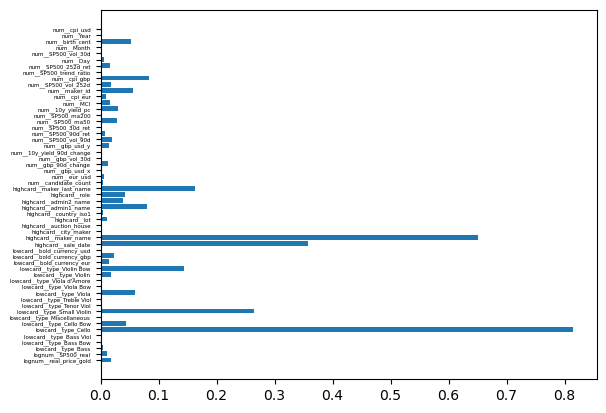

<Figure size 1200x600 with 0 Axes>

In [23]:


abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=4)
plt.figure(figsize=(12,6))
plt.show()

Next I will drop some features which had a zero coefficient and run the random forest model again to see if there are any changes.

In [ ]:
zerofeatures_extract = []
for x in zerofeatures:
    if "highcard" in x:
        zerofeatures_extract.append(x.split("_",2)[-1].strip("'\'"))
    elif "num" in x:
         zerofeatures_extract.append(x.split("_",2)[-1].strip("'\'"))
for x in zerofeatures_extract:
    print(x)

city_maker
gbp_usd_x
SP500_30d_ret
SP500_ma200
SP500_trend_ratio
SP500_vol_30d
Year
cpi_usd


In [ ]:
#preparing new train and validation sets
train_new = train.drop(columns = zerofeatures_extract)
valid_new = valid.drop(columns = zerofeatures_extract)

X_train_new = train_new.iloc[:, train_new.columns != 'price_usd_real']
X_valid_new = valid_new.iloc[:, train_new.columns != 'price_usd_real']
Y_train_new = train_new.iloc[:, train_new.columns == 'price_usd_real']
Y_valid_new = valid_new.iloc[:, train_new.columns == 'price_usd_real']




In [110]:
HighCardCols_new = ["sale_date", "maker_name", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

#new features with numerical values
numberdtype_new = X_train_new.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols_new = list( set(numberdtype_new) - set(LogColumns))


In [106]:
preprocessor_new = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols_new ) ,
        ('num', Numerical_transformer, NumericalCols_new )],
        remainder = 'passthrough',
        sparse_threshold=0
)

In [107]:
pipeline_randomforest_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])


In [108]:
rf_new = pipeline_randomforest_new.fit(X_train_new, np.log1p(Y_train_new))


In [109]:
#converting predictions back to USD
forest_pred_new = np.expm1(rf_new.predict(X_valid_new))

rmse = mean_squared_error(Y_valid_new, forest_pred_new)
r2 = r2_score(Y_valid_new, forest_pred_new)
mae = mean_absolute_error(Y_valid_new, forest_pred_new)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)


RMSE: 9799747089.63122
R^2: 0.6948227851641444
mae: 7706.118253213228
